In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import MACCSkeys

In [2]:
import random
import numpy as np
import pandas as pd
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, roc_auc_score, matthews_corrcoef

In [4]:
import matplotlib.pyplot as plt

In [5]:
df1 = pd.read_csv('./ido1_tdo_fulljoin_20260205.csv', na_values=['na'])
#df1 = df1.dropna(ignore_index=True)
df1

,molecule_chembl_id,smiles,ido1_ic50,tdo_ic50
0,CHEMBL412131,Cc1c(SC[C@H](NC(=O)CC[C@H](N)C(=O)O)C(=O)NCC(=...,340.0,NaN
1,CHEMBL565489,Cc1cccc(N/C(=N\O)c2nonc2N)c1,550.0,NaN
2,CHEMBL107103,O=C(c1ccccc1)c1cccc(O)c1,500000.0,NaN
3,CHEMBL3342385,CCOC(=O)c1cnc2scc(C3=CCCCC3)n12,100000.0,NaN
4,CHEMBL3765545,O=C1CCc2cc(S(=O)(=O)NNc3ccc(Br)cc3)ccc2N1,72.7,NaN
...,...,...,...,...
4586,CHEMBL6053460,N#Cc1cc(-c2c[nH]c3cc(F)ccc23)ccc1S(=O)(=O)N1CC...,NaN,730.0
4587,CHEMBL5819188,NC(=O)CNc1ccc(-c2c[nH]c3cc(F)ccc23)cn1,NaN,790.0
4588,CHEMBL4849018,OCC(O)Cn1nnc2ccc(-c3c[nH]c4ccccc34)cc21,NaN,25200.0
4589,CHEMBL4176841,Cc1ccn(-c2cnoc2N)n1,NaN,1600.0


In [6]:
df2 = df1.loc[:, ['ido1_ic50', 'tdo_ic50']]
df2

,ido1_ic50,tdo_ic50
0,340.0,NaN
1,550.0,NaN
2,500000.0,NaN
3,100000.0,NaN
4,72.7,NaN
...,...,...
4586,NaN,730.0
4587,NaN,790.0
4588,NaN,25200.0
4589,NaN,1600.0


In [7]:
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] <= 1000:
        df2.loc[i, ['ido1_ic50']] = 1
    elif df2['ido1_ic50'].values[i] > 1000:
        df2.loc[i, ['ido1_ic50']] = 0
    else:
        df2.loc[i, ['ido1_ic50']] = np.nan

In [8]:
for i in range(len(df2)):
    if df2['tdo_ic50'].values[i] <= 1000:
        df2.loc[i, ['tdo_ic50']] = 1
    elif df2['tdo_ic50'].values[i] > 1000:
        df2.loc[i, ['tdo_ic50']] = 0
    else:
        df2.loc[i, ['tdo_ic50']] = np.nan

In [9]:
df2

,ido1_ic50,tdo_ic50
0,1.0,NaN
1,1.0,NaN
2,0.0,NaN
3,0.0,NaN
4,1.0,NaN
...,...,...
4586,NaN,1.0
4587,NaN,1.0
4588,NaN,0.0
4589,NaN,0.0


In [10]:
newcol = []
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('AA')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('II')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('IA')
    elif df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('AI')
    else:
        newcol.append(np.nan)

In [11]:
len(newcol)

4591

In [12]:
target = pd.DataFrame(data=newcol, columns=['ido_tdo'])
target

,ido_tdo
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4586,NaN
4587,NaN
4588,NaN
4589,NaN


In [13]:
y = target.values.reshape(len(df2),)
y.shape

(4591,)

In [14]:
#Identify labeled nodes
# Boolean mask for labeled nodes
labeled_mask = target['ido_tdo'].notna()

# Get indices of labeled nodes
labeled_indices = target.index[labeled_mask].to_numpy()  # 1126 nodes


In [15]:
labeled_indices.shape

(1126,)

In [16]:
labeled_indices

array([3294, 3295, 3296, ..., 4417, 4418, 4419])

In [17]:
y[labeled_indices]

array(['AA', 'AI', 'II', ..., 'II', 'AA', 'AI'], dtype=object)

In [18]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_label = encoder.fit_transform(y[labeled_indices])

In [19]:
y_label

array([0, 1, 3, ..., 3, 0, 1])

In [20]:
# Random & Stratify split
from sklearn.model_selection import train_test_split

def stratified_split_indices(labeled_indices, y_label, train_ratio=0.6, val_ratio=0.2, seed=42):
    """
    Stratified split of labeled_indices into train/val/test, stratified by y_label.
    Returns train_idx, val_idx, test_idx (subsets of labeled_indices).
    """
    labeled_indices = np.asarray(labeled_indices)
    y_label = np.asarray(y_label)

    test_ratio = 1.0 - train_ratio - val_ratio

    # First split: train vs (val+test)
    train_idx, temp_idx, train_y, temp_y = train_test_split(
        labeled_indices,
        y_label,
        train_size=train_ratio,
        stratify=y_label,
        random_state=seed
    )

    # Second split: val vs test (relative proportions within temp)
    val_size_relative = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx, val_y, test_y = train_test_split(
        temp_idx,
        temp_y,
        train_size=val_size_relative,
        stratify=temp_y,
        random_state=seed
    )

    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = stratified_split_indices(
    labeled_indices,
    y_label,
    train_ratio=0.6,
    val_ratio=0.2,
    seed=42
)

print("Train size:", len(train_idx))
print("Val size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 675
Val size: 225
Test size: 226


In [21]:
test_idx

array([3457, 4103, 4032, 3977, 4338, 4397, 3384, 3980, 3701, 3316, 4092,
       4376, 3371, 4391, 4142, 3839, 4043, 4320, 3519, 3708, 3309, 4089,
       4333, 4304, 3975, 3778, 3827, 3840, 4352, 3541, 3386, 3781, 3566,
       4183, 3817, 3436, 4019, 4189, 4126, 4359, 4314, 4281, 4131, 4389,
       3875, 3864, 3713, 3556, 3377, 3843, 3725, 3815, 3339, 4402, 3887,
       4245, 3325, 3343, 3605, 3806, 3883, 3299, 4400, 3712, 4169, 3986,
       3594, 3439, 3836, 3695, 3640, 3393, 4097, 3928, 3334, 4080, 3925,
       4177, 4102, 4416, 3767, 4306, 3608, 3312, 4337, 4387, 3766, 3729,
       3336, 4152, 3646, 4283, 3903, 4063, 3523, 4231, 4275, 3978, 4111,
       3991, 3349, 3771, 3546, 3406, 3997, 4095, 3841, 4011, 3460, 3944,
       4280, 3650, 4414, 3586, 3629, 4106, 3426, 3633, 3671, 4296, 3392,
       3507, 4322, 3770, 3964, 4137, 3893, 3524, 4184, 3411, 4383, 4143,
       3535, 3619, 3331, 4157, 4091, 3896, 3310, 4161, 4317, 3804, 4410,
       3500, 3545, 3321, 3832, 4265, 4236, 3953, 41

In [22]:
#With stratified split:
len(train_idx), len(val_idx), len(test_idx)

(675, 225, 226)

In [23]:
#Create PyG masks
num_nodes = len(target)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True


In [24]:
train_mask.size(), test_mask.size()

(torch.Size([4591]), torch.Size([4591]))

In [25]:
train_idx.shape

(675,)

In [26]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()

In [27]:
mols = []
for i in range(len(df1)):
    try:
        mol_i = Chem.MolFromSmiles(df1['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols.append(mol_i)
    except Exception as e:
        print(e)
len(mols)

4591

In [28]:
smiles_list = [df1['smiles'][i] for i in range(len(df1['smiles']))]

In [29]:
names_list = [df1['molecule_chembl_id'][i] for i in range(len(df1['molecule_chembl_id']))]

In [ ]:
#Deprecated method for Morgan as ExplicitBitVect
FPs = [AllChem.GetMorganFingerprintAsBitVect(mols[i], radius=3, nBits=1024) for i in range(len(mols))]

In [34]:
sim_mat_tanimoto = np.zeros((len(FPs), len(FPs)))
sim_mat_dice = np.zeros((len(FPs), len(FPs)))
sim_mat_cosine = np.zeros((len(FPs), len(FPs)))

In [35]:
#Calculate the diagonal elements
for i in range(len(FPs)):
    for j in range(i, len(FPs)):  # Avoid duplicate calculations
        similarity = DataStructs.TanimotoSimilarity(FPs[i], FPs[j])
        sim_mat_tanimoto[i, j] = similarity
        sim_mat_tanimoto[j, i] = similarity

In [36]:
#Calculate the diagonal elements
for i in range(len(FPs)):
    for j in range(i, len(FPs)):  # Avoid duplicate calculations
        similarity = DataStructs.DiceSimilarity(FPs[i], FPs[j])
        sim_mat_dice[i, j] = similarity
        sim_mat_dice[j, i] = similarity

In [37]:
#Calculate the diagonal elements
for i in range(len(FPs)):
    for j in range(i, len(FPs)):  # Avoid duplicate calculations
        similarity = DataStructs.CosineSimilarity(FPs[i], FPs[j])
        sim_mat_cosine[i, j] = similarity
        sim_mat_cosine[j, i] = similarity

In [38]:
import seaborn as sns

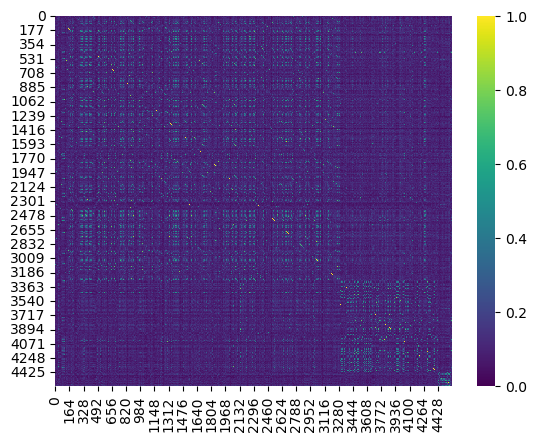

In [39]:
#Tanimoto
sns.heatmap(sim_mat_tanimoto, cmap='viridis');

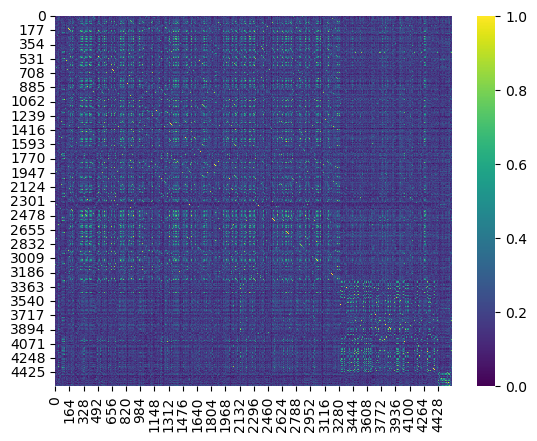

In [40]:
#Dice
sns.heatmap(sim_mat_dice, cmap='viridis');

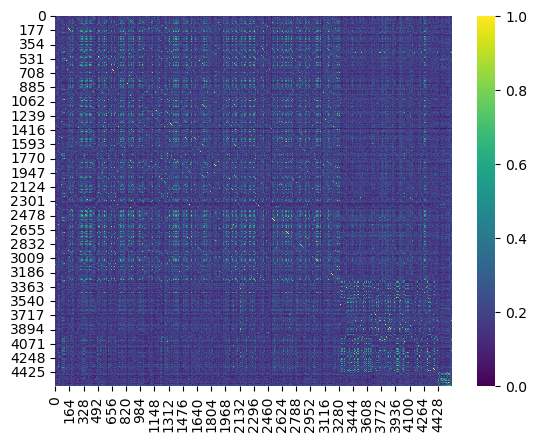

In [41]:
#Cosine
sns.heatmap(sim_mat_cosine, cmap='viridis');

In [45]:
sim_mat_tanimoto.min(), sim_mat_tanimoto.max(), sim_mat_tanimoto.mean()

(0.0, 1.0, 0.11476852948471082)

In [46]:
sim_mat_dice.min(), sim_mat_dice.max(), sim_mat_dice.mean()

(0.0, 1.0, 0.19972533915881202)

In [47]:
sim_mat_cosine.min(), sim_mat_cosine.max(), sim_mat_cosine.mean()

(0.0, 1.0, 0.2030562961388942)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x73869458c0e0>],
 'cmeans': <matplotlib.collections.LineCollection at 0x73869455cbf0>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x73869e9270b0>,
 'cmins': <matplotlib.collections.LineCollection at 0x73869e728b60>,
 'cbars': <matplotlib.collections.LineCollection at 0x73869455f740>,
 'cmedians': <matplotlib.collections.LineCollection at 0x738694575250>}

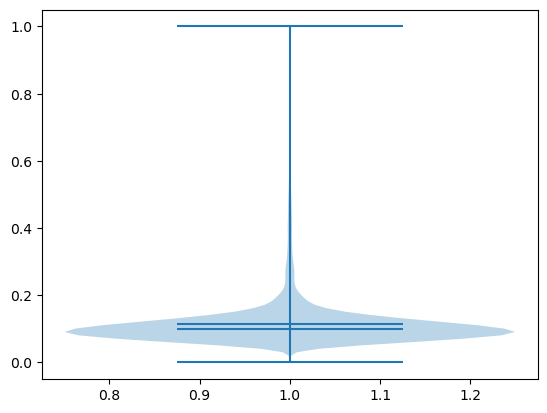

In [42]:
#Tanimoto
plt.violinplot(sim_mat_tanimoto.flatten(), showmeans=True, showmedians=True)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x73869e05e3f0>],
 'cmeans': <matplotlib.collections.LineCollection at 0x73869e72e300>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x73869e72a900>,
 'cmins': <matplotlib.collections.LineCollection at 0x73869e05f7a0>,
 'cbars': <matplotlib.collections.LineCollection at 0x738694499a60>,
 'cmedians': <matplotlib.collections.LineCollection at 0x73869e190ce0>}

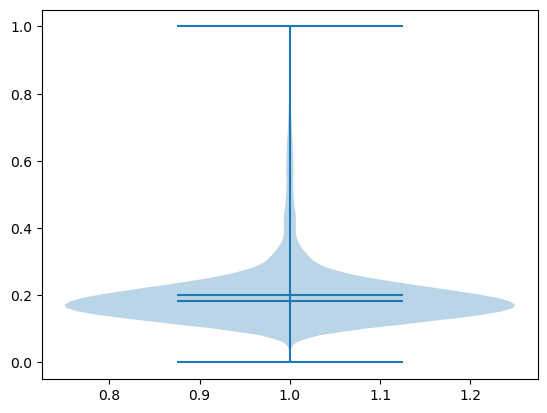

In [43]:
#Dice
plt.violinplot(sim_mat_dice.flatten(), showmeans=True, showmedians=True)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x73869e581250>],
 'cmeans': <matplotlib.collections.LineCollection at 0x73869e72ef00>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x73869eb8bce0>,
 'cmins': <matplotlib.collections.LineCollection at 0x73869e582d20>,
 'cbars': <matplotlib.collections.LineCollection at 0x7386944ab4a0>,
 'cmedians': <matplotlib.collections.LineCollection at 0x73869449bb00>}

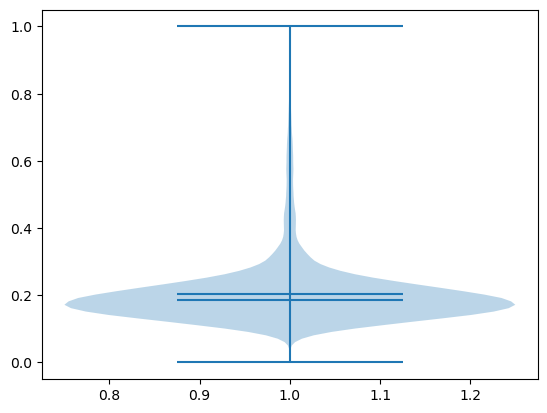

In [44]:
#Cosine
plt.violinplot(sim_mat_cosine.flatten(), showmeans=True, showmedians=True)

In [48]:
import networkx as nx

In [49]:
#Build k-NN graph from similarity matrix
k = 15  # start with 10–20

In [50]:
#Mutual k-NN (Tanimoto)
#This avoids hubs:
max_w = np.max(sim_mat_tanimoto ** 2)
edges = set()
num_nodes = sim_mat_tanimoto.shape[0]
for i in range(num_nodes):
    sims = sim_mat_tanimoto[i]
    nn_idx = np.argsort(sims)[::-1][1:k+1]
    for j in nn_idx:
        edges.add((i, j))

G1 = nx.Graph()
for i, j in edges:
    if (j, i) in edges:
        w = (sim_mat_tanimoto[i, j]**2) / max_w
        G1.add_edge(i, j, weight=w)

In [51]:
#Mutual k-NN (Dice)
#This avoids hubs:
max_w = np.max(sim_mat_dice ** 2)
edges = set()
num_nodes = sim_mat_dice.shape[0]
for i in range(num_nodes):
    sims = sim_mat_dice[i]
    nn_idx = np.argsort(sims)[::-1][1:k+1]
    for j in nn_idx:
        edges.add((i, j))

G2 = nx.Graph()
for i, j in edges:
    if (j, i) in edges:
        w = (sim_mat_dice[i, j]**2) / max_w
        G2.add_edge(i, j, weight=w)

In [52]:
#Mutual k-NN (Cosine)
#This avoids hubs:
max_w = np.max(sim_mat_cosine ** 2)
edges = set()
num_nodes = sim_mat_cosine.shape[0]
for i in range(num_nodes):
    sims = sim_mat_cosine[i]
    nn_idx = np.argsort(sims)[::-1][1:k+1]
    for j in nn_idx:
        edges.add((i, j))

G3 = nx.Graph()
for i, j in edges:
    if (j, i) in edges:
        w = (sim_mat_cosine[i, j]**2) / max_w
        G3.add_edge(i, j, weight=w)

In [53]:
len(G1.nodes), len(G1.edges)

(4510, 22254)

In [54]:
len(G2.nodes), len(G2.edges)

(4510, 22254)

In [55]:
len(G3.nodes), len(G3.edges)

(4505, 22198)

In [48]:
#Step 1: Compute Morgan fingerprints

In [56]:
# Suppose you have a list of SMILES strings for your dataset
def morgan_fp(smiles, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    fpgen = AllChem.GetMorganGenerator(fpSize=1024)
    arr_fp = fpgen.GetFingerprintAsNumPy(mol)
    return arr_fp

node_features = np.array([morgan_fp(s) for s in smiles_list])  # shape (4591, 1024)

In [57]:
node_features.shape

(4591, 1024)

In [58]:
#For PyG, node labels should be integers (0–3 for 4 classes).
# Map class names to integers
class_mapping = {'AA': 0, 'AI': 1, 'IA': 2, 'II': 3}
labels = target['ido_tdo'].map(class_mapping)

# Replace NaN with -1 (unlabeled)
labels = labels.fillna(-1).astype(int)

y = torch.tensor(labels.values, dtype=torch.long)

In [59]:
y

tensor([-1, -1, -1,  ..., -1, -1, -1])

In [60]:
#In the following steps, we are preparing and converting the data to a pytorch compatible input data.

In [61]:
#Step 2: Build edge list with weights from NetworkX

In [62]:
import torch
from torch_geometric.data import Data

# Assume G is your weighted NetworkX graph
edge_index = []
edge_attr = []

for u, v, data in G1.edges(data=True):
    edge_index.append([u, v])
    edge_index.append([v, u])  # undirected graph → add both directions
    edge_attr.append([data['weight']])
    edge_attr.append([data['weight']])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
edge_attr = torch.tensor(edge_attr, dtype=torch.float)                   

In [63]:
#Step 3: Add node features and labels

In [64]:
# Convert node features to tensor
x = torch.tensor(node_features, dtype=torch.float)  # shape [4591, 1024]

In [65]:
#Step 4: Create PyTorch Geometric Data object

In [66]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
print(data)

Data(x=[4591, 1024], edge_index=[2, 44508], edge_attr=[44508, 1], y=[4591])


In [67]:
data.edge_attr.shape

torch.Size([44508, 1])

In [68]:
# Attach to data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

In [69]:
data.train_mask.sum()

tensor(675)

In [70]:
# Assuming your Data object is already built with x, edge_index, edge_attr, y

print("Train nodes:", data.train_mask.sum().item())
print("Val nodes:", data.val_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())

Train nodes: 675
Val nodes: 225
Test nodes: 226


In [71]:
data.has_self_loops(), data.has_isolated_nodes()

(True, True)

In [72]:
#Node classification task

In [73]:
data.num_classes = 4

In [74]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [75]:
#GCN model
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, LayerNorm


class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.5):
        super().__init__()

        # ----- GCN layers -----
        self.conv1 = GCNConv(num_features, 64)
        self.ln1 = LayerNorm(64)

        self.conv2 = GCNConv(64, 32)
        self.ln2 = LayerNorm(32)

        self.conv3 = GCNConv(32, 16)

        # ----- Skip connections -----
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)

        # ----- Classifier -----
        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_weight=None):
        # ===== Layer 1 =====
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)
        h = self.ln1(h)
        h = self.dropout(h)

        # ===== Layer 2 =====
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)
        h = self.ln2(h)
        h = self.dropout(h)

        # ===== Layer 3 =====
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [76]:
# Transductive GCN

data = data.to(device)
model = GCN(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax output
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())  # Consistent edge_weight
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(200):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping and checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gcn_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")
        

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model for final test - SECURE
checkpoint = torch.load('best_gcn_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


Train/Val/Test nodes: 675/225/226
Epoch 000 | Train Loss: 1.5249 | Train Acc: 0.2178 | Val Loss: 1.2068 | Val Acc: 0.5022 | Best: 0.5022
Epoch 010 | Train Loss: 0.8239 | Train Acc: 0.6830 | Val Loss: 0.7738 | Val Acc: 0.7067 | Best: 0.7067
Epoch 020 | Train Loss: 0.6419 | Train Acc: 0.7793 | Val Loss: 0.6547 | Val Acc: 0.7378 | Best: 0.7378
Epoch 030 | Train Loss: 0.5294 | Train Acc: 0.8089 | Val Loss: 0.6631 | Val Acc: 0.7422 | Best: 0.7556
Epoch 040 | Train Loss: 0.4300 | Train Acc: 0.8296 | Val Loss: 0.6948 | Val Acc: 0.7467 | Best: 0.7644
Epoch 050 | Train Loss: 0.3869 | Train Acc: 0.8444 | Val Loss: 0.7774 | Val Acc: 0.7422 | Best: 0.7644
Epoch 060 | Train Loss: 0.3441 | Train Acc: 0.8533 | Val Loss: 0.8230 | Val Acc: 0.7333 | Best: 0.7644
Epoch 070 | Train Loss: 0.3045 | Train Acc: 0.8874 | Val Loss: 0.9508 | Val Acc: 0.7244 | Best: 0.7644
Epoch 080 | Train Loss: 0.2807 | Train Acc: 0.8904 | Val Loss: 0.9658 | Val Acc: 0.7111 | Best: 0.7644
Early stopping at epoch 85
Test Loss: 0

In [77]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.716     0.849     0.777        86
           1      0.754     0.676     0.713        68
           2      0.600     0.300     0.400        10
           3      0.793     0.742     0.767        62

    accuracy                          0.743       226
   macro avg      0.716     0.642     0.664       226
weighted avg      0.743     0.743     0.738       226



In [78]:
import torch.nn.functional as F

In [79]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [80]:
y_true.shape

torch.Size([226])

In [81]:
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.9102583103947908

In [82]:
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average=None)

array([0.90398671, 0.9153481 , 0.90185185, 0.91984658])

In [83]:
matthews_corrcoef(y_true, y_pred)

0.6234514786143649

# **Dice similarity**

In [84]:
import torch
from torch_geometric.data import Data

# Assume G is your weighted NetworkX graph
edge_index = []
edge_attr = []

for u, v, data in G2.edges(data=True):
    edge_index.append([u, v])
    edge_index.append([v, u])  # undirected graph → add both directions
    edge_attr.append([data['weight']])
    edge_attr.append([data['weight']])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()  # shape [2, num_edges]
edge_attr = torch.tensor(edge_attr, dtype=torch.float)                   # shape [num_edges, 1]

In [85]:
# Convert node features to tensor
x = torch.tensor(node_features, dtype=torch.float)  # shape [4591, 1024]

In [86]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
print(data)

Data(x=[4591, 1024], edge_index=[2, 44508], edge_attr=[44508, 1], y=[4591])


In [88]:
# Attach to data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

In [89]:
data.num_classes = 4

In [90]:
# Transductive GCN

data = data.to(device)
model = GCN(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax output
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())  # Consistent edge_weight
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(200):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping and checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gcn_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")
        

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model for final test - SECURE
checkpoint = torch.load('best_gcn_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


Train/Val/Test nodes: 675/225/226
Epoch 000 | Train Loss: 1.5884 | Train Acc: 0.2667 | Val Loss: 1.2815 | Val Acc: 0.4533 | Best: 0.4533
Epoch 010 | Train Loss: 0.8280 | Train Acc: 0.7126 | Val Loss: 0.7874 | Val Acc: 0.7067 | Best: 0.7067
Epoch 020 | Train Loss: 0.6613 | Train Acc: 0.7585 | Val Loss: 0.6754 | Val Acc: 0.7378 | Best: 0.7378
Epoch 030 | Train Loss: 0.5354 | Train Acc: 0.7926 | Val Loss: 0.6627 | Val Acc: 0.7467 | Best: 0.7467
Epoch 040 | Train Loss: 0.4576 | Train Acc: 0.8326 | Val Loss: 0.6936 | Val Acc: 0.7200 | Best: 0.7467
Epoch 050 | Train Loss: 0.4101 | Train Acc: 0.8326 | Val Loss: 0.7330 | Val Acc: 0.7511 | Best: 0.7556
Epoch 060 | Train Loss: 0.3405 | Train Acc: 0.8770 | Val Loss: 0.8107 | Val Acc: 0.7511 | Best: 0.7644
Epoch 070 | Train Loss: 0.3149 | Train Acc: 0.8696 | Val Loss: 0.8916 | Val Acc: 0.7111 | Best: 0.7644
Epoch 080 | Train Loss: 0.2937 | Train Acc: 0.8756 | Val Loss: 0.9215 | Val Acc: 0.7244 | Best: 0.7644
Epoch 090 | Train Loss: 0.2433 | Train 

In [91]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.691     0.779     0.732        86
           1      0.694     0.632     0.662        68
           2      0.429     0.300     0.353        10
           3      0.767     0.742     0.754        62

    accuracy                          0.704       226
   macro avg      0.645     0.613     0.625       226
weighted avg      0.701     0.704     0.700       226



In [92]:
proba = F.softmax(out_test, dim=1)
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.9005897830505705

In [93]:
matthews_corrcoef(y_true, y_pred)

0.5654185580415955

# **Cosine similarity**

In [94]:
import torch
from torch_geometric.data import Data

# Assume G is your weighted NetworkX graph
edge_index = []
edge_attr = []

for u, v, data in G3.edges(data=True):
    edge_index.append([u, v])
    edge_index.append([v, u])  # undirected graph → add both directions
    edge_attr.append([data['weight']])
    edge_attr.append([data['weight']])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()  # shape [2, num_edges]
edge_attr = torch.tensor(edge_attr, dtype=torch.float)                   # shape [num_edges, 1]

In [95]:
# Convert node features to tensor
x = torch.tensor(node_features, dtype=torch.float)  # shape [4591, 1024]

In [96]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
print(data)

Data(x=[4591, 1024], edge_index=[2, 44396], edge_attr=[44396, 1], y=[4591])


In [97]:
# Attach to data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

In [98]:
data.num_classes = 4

In [99]:
# Transductive GCN

data = data.to(device)
model = GCN(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax output
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())  # Consistent edge_weight
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(200):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping and checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gcn_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")
        

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model for final test - SECURE
checkpoint = torch.load('best_gcn_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


Train/Val/Test nodes: 675/225/226
Epoch 000 | Train Loss: 1.6478 | Train Acc: 0.0785 | Val Loss: 1.3689 | Val Acc: 0.2089 | Best: 0.2089
Epoch 010 | Train Loss: 0.8768 | Train Acc: 0.7126 | Val Loss: 0.8068 | Val Acc: 0.7333 | Best: 0.7333
Epoch 020 | Train Loss: 0.6680 | Train Acc: 0.7585 | Val Loss: 0.7001 | Val Acc: 0.7422 | Best: 0.7467
Epoch 030 | Train Loss: 0.5365 | Train Acc: 0.7926 | Val Loss: 0.6916 | Val Acc: 0.7289 | Best: 0.7467
Epoch 040 | Train Loss: 0.4878 | Train Acc: 0.8104 | Val Loss: 0.6827 | Val Acc: 0.7422 | Best: 0.7467
Epoch 050 | Train Loss: 0.4210 | Train Acc: 0.8281 | Val Loss: 0.7177 | Val Acc: 0.7378 | Best: 0.7467
Epoch 060 | Train Loss: 0.3633 | Train Acc: 0.8593 | Val Loss: 0.8112 | Val Acc: 0.7289 | Best: 0.7467
Early stopping at epoch 62
Test Loss: 0.7861 | Test Acc: 0.6991


In [100]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.667     0.837     0.742        86
           1      0.714     0.588     0.645        68
           2      0.400     0.200     0.267        10
           3      0.772     0.710     0.739        62

    accuracy                          0.699       226
   macro avg      0.638     0.584     0.598       226
weighted avg      0.698     0.699     0.691       226



In [101]:
proba = F.softmax(out_test, dim=1)
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8746588919109316

In [102]:
matthews_corrcoef(y_true, y_pred)

0.5589786607828802